# Projeto Final: RideSmart

## Modelagem e Análise de Rotas Urbanas com Grafos

Aluno: Matheus Rodrigues Marinho

Disciplina: Estrutura de Dados II (DCA3702, Unidade 3)

---

### Problema

Dado um ponto de origem A (UFRN), um destino B (Midway Mall) e uma distância máxima de caminhada X = 500m, encontrar o melhor ponto de embarque P tal que P esteja a no máximo X metros de caminhada de A.

```
A → P  (caminhada)
P → B  (carro)
```

### Algoritmos comparados

1. Dijkstra Simples (busca linear, sem heap)
2. Dijkstra com Heap (fila de prioridade)
3. A* com heurística geográfica (haversine)
4. Dijkstra Bidirecional

## 1. Configuração e Importações

In [1]:
import osmnx as ox
import networkx as nx
import heapq
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

AUTOR = 'Matheus Rodrigues Marinho'
_savefig_original = plt.savefig

def _savefig_assinado(*args, **kwargs):
    plt.gcf().text(0.99, 0.01, AUTOR, ha='right', va='bottom',
                   fontsize=8, color='#999999')
    return _savefig_original(*args, **kwargs)

plt.savefig = _savefig_assinado

## 2. Download e Preparação do Grafo

A rede viária é obtida via OSMnx a partir do OpenStreetMap.
A área cobre Lagoa Nova e arredores, englobando UFRN e Midway Mall.

- Nós representam interseções e endpoints de ruas.
- Arestas representam segmentos de rua, com atributos de comprimento, velocidade e tipo de via.
- O grafo é um MultiDiGraph (direcionado, com arestas paralelas), preservando mão única.

Nós: 3374
Arestas: 8014
Tipo: MultiDiGraph


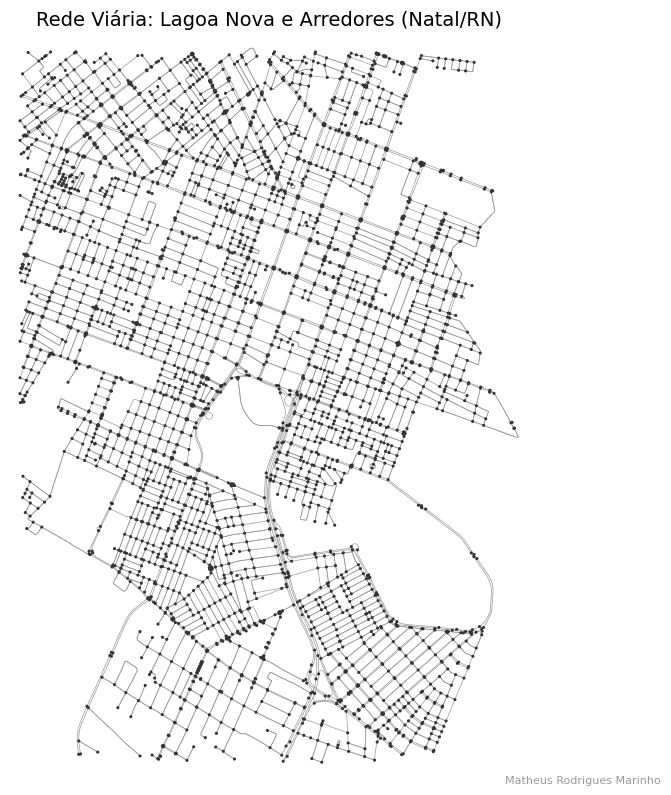

In [2]:
center = (-5.827, -35.204)
G = ox.graph_from_point(center, dist=3000, network_type='drive')

print(f'Nós: {G.number_of_nodes()}')
print(f'Arestas: {G.number_of_edges()}')
print(f'Tipo: {type(G).__name__}')

fig, ax = ox.plot_graph(G, node_size=5, node_color='#333333',
                        edge_color='#999999', edge_linewidth=0.5,
                        bgcolor='white', show=False, close=False)
ax.set_title('Rede Viária: Lagoa Nova e Arredores (Natal/RN)', fontsize=14)
plt.tight_layout()
plt.savefig('../imagens/01_rede_completa.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Modelagem dos Pesos

Três funções de custo são definidas para as arestas:

| Peso | Atributo | Descrição |
|------|----------|-----------|
| Distância | `length` | Comprimento do segmento em metros |
| Tempo livre | `travel_time` | Tempo de percurso baseado na velocidade da via (sem trânsito) |
| Tempo com trânsito | `travel_time_traffic` | Tempo com congestionamento sintético |

In [3]:
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

speeds = [data.get('speed_kph', 0) for _, _, _, data in G.edges(keys=True, data=True)]
print(f'Velocidade média: {np.mean(speeds):.1f} km/h')
print(f'Velocidade máx:   {np.max(speeds):.1f} km/h')
print(f'Velocidade mín:   {np.min(speeds):.1f} km/h')

Velocidade média: 38.3 km/h
Velocidade máx:   80.0 km/h
Velocidade mín:   20.0 km/h


### 3.1 Trânsito Sintético: um "Dia Típico" por Hora

O congestionamento é modelado como um dia típico, um padrão que assumimos se repetir em todo dia útil, combinando dois eixos:

- ONDE (espacial): hierarquia viária (avenidas saturam mais que ruas residenciais) + corredores arteriais reais identificados pelo nome no OSM (com destaque para a Av. Senador Salgado Filho). Essas vias recebem um reforço de congestionamento.
- QUANDO (temporal): um perfil de intensidade por hora (0h-23h), bimodal como em qualquer capital, pico de manhã (~7-8h), repique no almoço e o pico mais forte no fim de tarde (~18h); de madrugada o trânsito é quase livre.

O fator de cada aresta, no horário escolhido, é:

$$\text{fator}(hora) = 1 + \text{inc}_{\text{base}} \cdot I(hora) \cdot \varepsilon$$

onde $\text{inc}_{\text{base}}$ é a severidade espacial (hierarquia + corredor), $I(hora)\in[0,1]$ é a intensidade daquele horário e $\varepsilon$ é um ruído de ±10% (incidentes pontuais).

Basta mudar a variável `HORA` (0 a 23) e reexecutar para simular qualquer momento do dia. Assumimos que esse perfil é representativo de um dia útil comum, uma simplificação explícita, já que não usamos dados reais de fluxo medido.

In [4]:
corredores_criticos = {
    'Avenida Senador Salgado Filho',
    'Avenida Prudente de Morais',
    'Avenida Nevaldo Rocha',
    'Avenida Amintas Barros',
    'Avenida Antônio Basílio',
    'Avenida Romualdo Galvão',
    'Avenida Nascimento de Castro',
    'Avenida Rui Barbosa',
}

INC = {
    'trunk': 0.80, 'trunk_link': 0.80,
    'primary': 0.90, 'primary_link': 0.90,
    'secondary': 0.70, 'secondary_link': 0.70,
    'tertiary': 0.40, 'tertiary_link': 0.40,
    'residential': 0.12, 'living_street': 0.08,
}
BOOST = 2.2

def _nome_via(data):
    name = data.get('name')
    if isinstance(name, list):
        name = name[0] if name else None
    return name

def incremento_base(data):
    """Severidade espacial da aresta no auge do pico (hierarquia + corredor)."""
    hw = data.get('highway', 'residential')
    if isinstance(hw, list):
        hw = hw[0]
    inc = INC.get(hw, 0.15)
    if _nome_via(data) in corredores_criticos:
        inc *= BOOST
    return inc

PERFIL_HORA = {
    0: 0.05, 1: 0.03, 2: 0.02, 3: 0.02, 4: 0.05, 5: 0.15,
    6: 0.45, 7: 0.85, 8: 0.95, 9: 0.70, 10: 0.50, 11: 0.55,
    12: 0.65, 13: 0.60, 14: 0.50, 15: 0.55, 16: 0.70, 17: 0.90,
    18: 1.00, 19: 0.85, 20: 0.55, 21: 0.35, 22: 0.20, 23: 0.10,
}

def aplicar_transito(G, hora, seed=42):
    """Recalcula travel_time_traffic de todas as arestas para a hora escolhida.
    fator = 1 + incremento_base * intensidade_da_hora * ruído(±10%)."""
    intens = PERFIL_HORA[hora]
    rng = random.Random(seed)
    stats = {'alta': 0, 'media': 0, 'baixa': 0}
    for u, v, k, data in G.edges(keys=True, data=True):
        jitter = rng.uniform(0.9, 1.1)
        factor = max(1.0, 1.0 + incremento_base(data) * intens * jitter)
        data['travel_time_traffic'] = data['travel_time'] * factor
        if factor >= 2.0:
            stats['alta'] += 1
        elif factor >= 1.4:
            stats['media'] += 1
        else:
            stats['baixa'] += 1
    return stats

HORA = 18

stats = aplicar_transito(G, HORA)
print(f'Trânsito do DIA TÍPICO aplicado para HORA = {HORA}h '
      f'(intensidade {PERFIL_HORA[HORA]:.0%} do pico)')
print(f'Corredores críticos: {len(corredores_criticos)} avenidas reais  |  reforço {BOOST}x\n')
print('Distribuição do congestionamento neste horário:')
for nivel, count in stats.items():
    print(f'  {nivel:>6}: {count} arestas ({count/G.number_of_edges()*100:.1f}%)')

Trânsito do DIA TÍPICO aplicado para HORA = 18h (intensidade 100% do pico)
Corredores críticos: 8 avenidas reais  |  reforço 2.2x

Distribuição do congestionamento neste horário:
    alta: 664 arestas (8.3%)
   media: 1882 arestas (23.5%)
   baixa: 5468 arestas (68.2%)


### 3.2 Perfil de Trânsito ao Longo do Dia

A curva abaixo mostra a intensidade do trânsito hora a hora no dia típico assumido. O padrão é bimodal: sobe no pico da manhã, dá uma trégua no meio do dia (com um repique no almoço) e atinge o auge no fim de tarde (~18h). A barra vermelha marca a hora atualmente simulada (`HORA`).

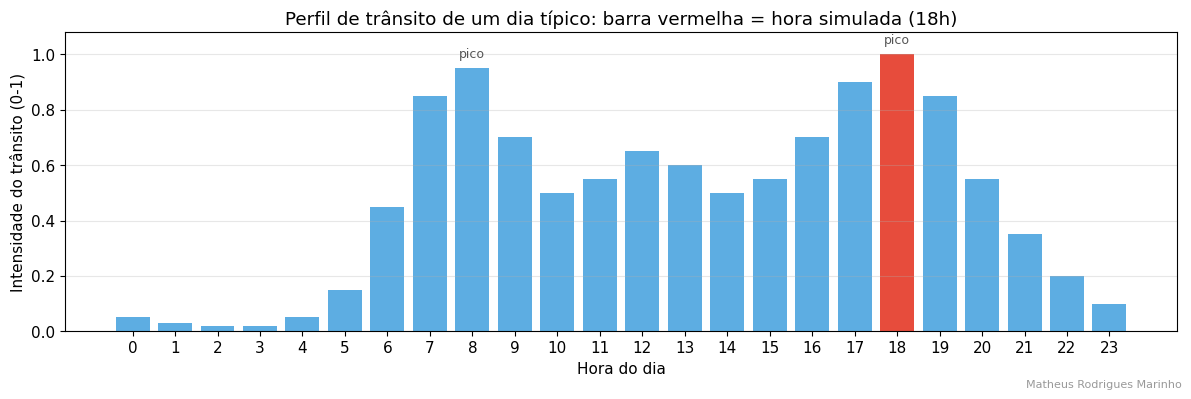

In [5]:
horas = list(range(24))
intensidades = [PERFIL_HORA[h] for h in horas]

fig, ax = plt.subplots(figsize=(12, 4))
cores = ['#e74c3c' if h == HORA else '#5dade2' for h in horas]
ax.bar(horas, intensidades, color=cores)
ax.set_xticks(horas)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Intensidade do trânsito (0-1)')
ax.set_title(f'Perfil de trânsito de um dia típico: barra vermelha = hora simulada ({HORA}h)')
ax.set_ylim(0, 1.08)
for h in (8, 18):
    ax.annotate('pico', xy=(h, PERFIL_HORA[h]), xytext=(h, PERFIL_HORA[h] + 0.04),
                ha='center', fontsize=9, color='#555')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../imagens/06_perfil_horario.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Comparação Visual entre Horários

A rede viária colorida pelo nível de congestionamento (verde = livre → vermelho = pesado) em quatro horários representativos do dia típico. Na madrugada (3h) quase toda a malha está verde; já às 18h os corredores arteriais, em especial a Av. Senador Salgado Filho, ficam vermelhos. A escala de cor é fixa entre os painéis, então a comparação é justa.

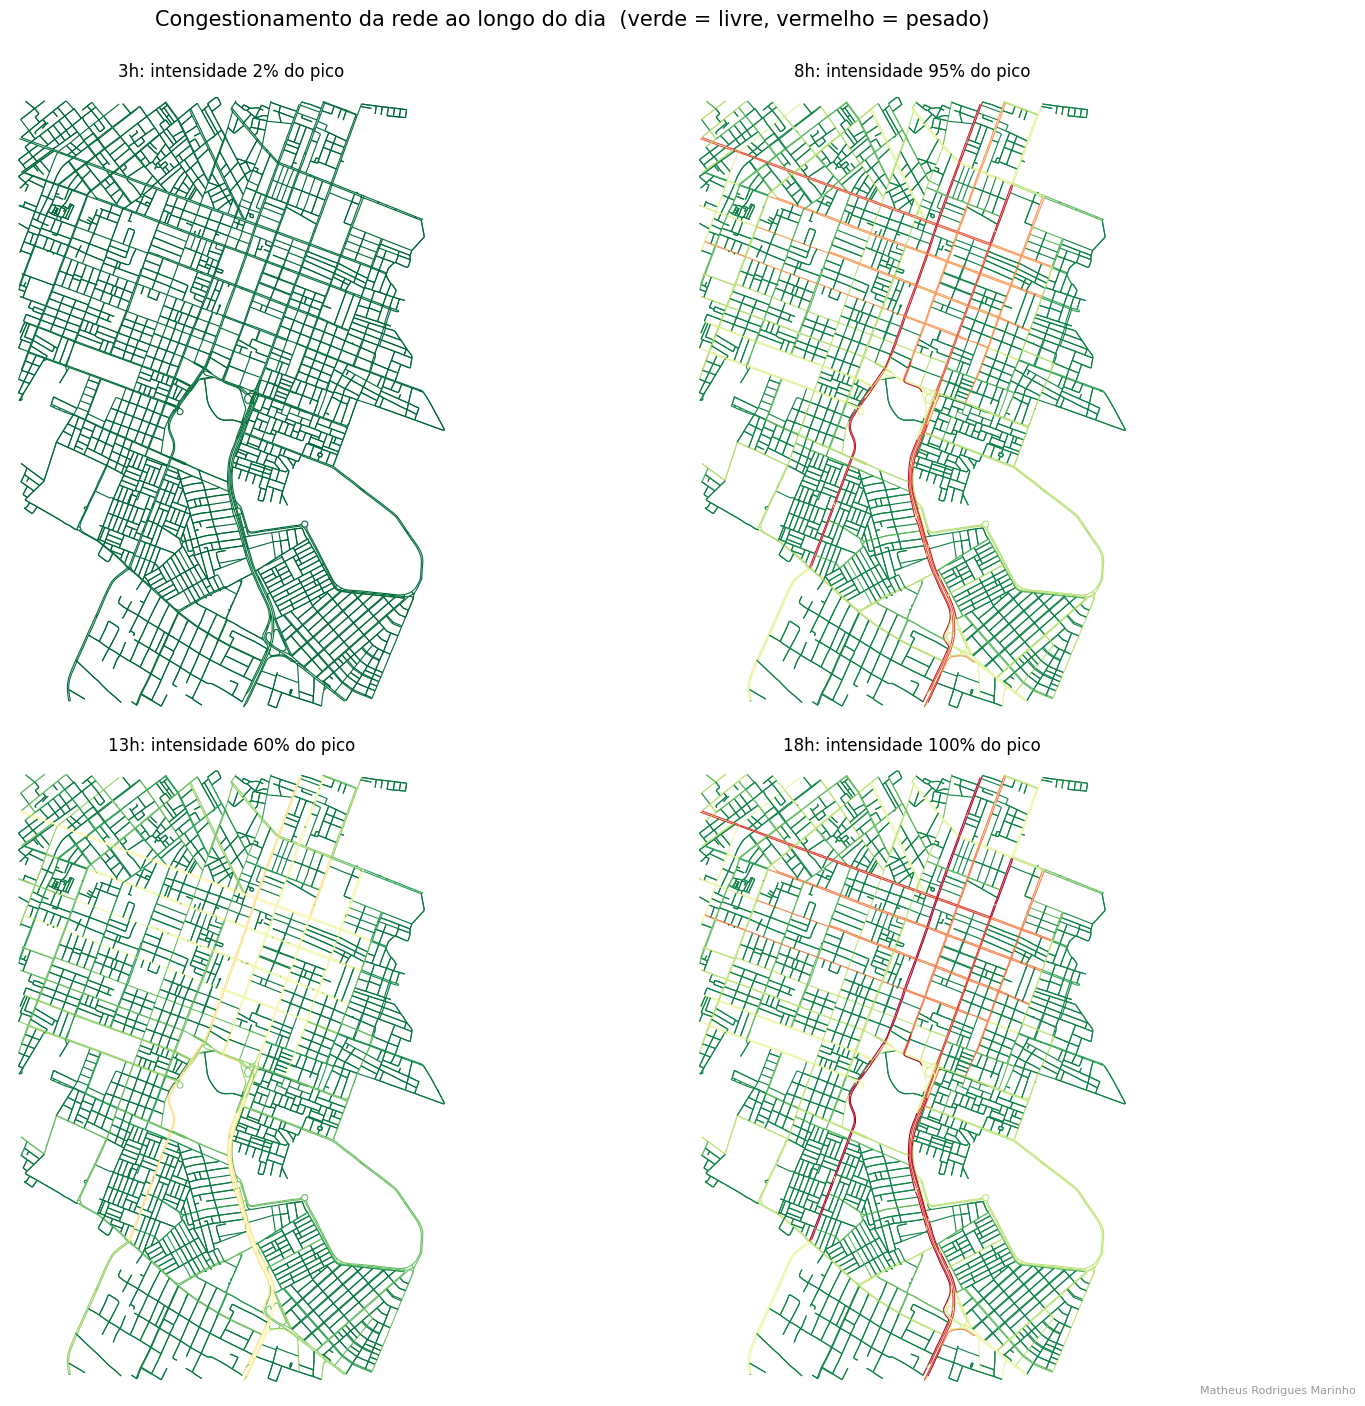

In [6]:
import matplotlib.colors as mcolors

cmap_cong = plt.get_cmap('RdYlGn_r')
VMAX = 3.0

def cores_congestionamento(G, hora):
    """Cor por aresta segundo o fator de congestionamento da hora (sem ruído), escala fixa."""
    intens = PERFIL_HORA[hora]
    cores = []
    for u, v, k, data in G.edges(keys=True, data=True):
        f = 1.0 + incremento_base(data) * intens
        t = min(1.0, (f - 1.0) / (VMAX - 1.0))
        cores.append(mcolors.to_hex(cmap_cong(t)))
    return cores

horas_snap = [3, 8, 13, 18]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, hora in zip(axes.ravel(), horas_snap):
    ec = cores_congestionamento(G, hora)
    ox.plot_graph(G, ax=ax, edge_color=ec, edge_linewidth=0.8, node_size=0,
                  bgcolor='white', show=False, close=False)
    ax.set_title(f'{hora}h: intensidade {PERFIL_HORA[hora]:.0%} do pico', fontsize=12)

plt.suptitle('Congestionamento da rede ao longo do dia  (verde = livre, vermelho = pesado)',
             fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig('../imagens/07_comparacao_horarios.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Mapa de Calor do Congestionamento (hora selecionada)

Mapa de calor do excesso de tempo sobre o fluxo livre para a hora atualmente simulada (`HORA`). As regiões quentes (laranja/vermelho) coincidem com os corredores arteriais reais, em especial a Av. Senador Salgado Filho, destacados em roxo seguindo a geometria verdadeira das vias.

In [7]:
from folium.plugins import HeatMap

heat_data = []
for u, v, k, data in G.edges(keys=True, data=True):
    tt = data.get('travel_time', 0)
    ttt = data.get('travel_time_traffic', tt)
    fator = (ttt / tt) if tt and tt > 0 else 1.0

    lat_m = (G.nodes[u]['y'] + G.nodes[v]['y']) / 2
    lon_m = (G.nodes[u]['x'] + G.nodes[v]['x']) / 2
    heat_data.append([lat_m, lon_m, max(0.0, fator - 1.0)])

mapa_calor = folium.Map(location=[center[0], center[1]], zoom_start=14, tiles='CartoDB positron')

HeatMap(
    heat_data,
    radius=13, blur=18, min_opacity=0.25, max_zoom=15,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1.0: 'red'}
).add_to(mapa_calor)

for u, v, k, data in G.edges(keys=True, data=True):
    if _nome_via(data) in corredores_criticos:
        geom = data.get('geometry')
        if geom is not None:
            coords = [(lat, lon) for lon, lat in geom.coords]
        else:
            coords = [(G.nodes[u]['y'], G.nodes[u]['x']), (G.nodes[v]['y'], G.nodes[v]['x'])]
        folium.PolyLine(coords, color='#8e44ad', weight=2.5, opacity=0.6).add_to(mapa_calor)

print('Mapa de calor do trânsito gerado.')
print('Azul/verde = fluxo livre  |  laranja/vermelho = forte congestionamento')
print('Linhas roxas = corredores arteriais reais (ex.: Av. Senador Salgado Filho)')
mapa_calor

Mapa de calor do trânsito gerado.
Azul/verde = fluxo livre  |  laranja/vermelho = forte congestionamento
Linhas roxas = corredores arteriais reais (ex.: Av. Senador Salgado Filho)


## 4. Definição de Origem e Destino

- Origem A: UFRN (Campus Central, perto da Reitoria)
- Destino B: Midway Mall
- Distância máxima de caminhada: 500 metros

In [8]:
lat_A, lon_A = -5.8425, -35.1997
lat_B, lon_B = -5.8113, -35.2072

MAX_WALK = 500
WALK_SPEED = 5.0 / 3.6

A = ox.nearest_nodes(G, X=lon_A, Y=lat_A)
B = ox.nearest_nodes(G, X=lon_B, Y=lat_B)

print(f'Origem A (UFRN):    nó {A}  ({G.nodes[A]["y"]:.6f}, {G.nodes[A]["x"]:.6f})')
print(f'Destino B (Midway): nó {B}  ({G.nodes[B]["y"]:.6f}, {G.nodes[B]["x"]:.6f})')

center_lat = (G.nodes[A]['y'] + G.nodes[B]['y']) / 2
center_lon = (G.nodes[A]['x'] + G.nodes[B]['x']) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='CartoDB positron')
folium.Marker([G.nodes[A]['y'], G.nodes[A]['x']],
              popup='A: UFRN', icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker([G.nodes[B]['y'], G.nodes[B]['x']],
              popup='B: Midway Mall', icon=folium.Icon(color='red', icon='stop')).add_to(m)
m

Origem A (UFRN):    nó 784697934  (-5.843800, -35.199449)
Destino B (Midway): nó 501699027  (-5.810857, -35.207774)


## 5. Implementação dos Algoritmos

Todos os algoritmos foram implementados manualmente (sem usar `networkx.shortest_path`),
retornando: (caminho, custo, nós expandidos).

### 5.1 Dijkstra Simples (sem Heap)

Implementação clássica com busca linear pelo nó não visitado de menor distância.

- Complexidade: O(V²). A cada iteração, percorre todos os nós para achar o mínimo.
- Serve de baseline para mostrar a ineficiência sem uma estrutura de dados adequada.

In [9]:
def dijkstra_simples(G, source, target, weight='length'):
    dist = {node: float('inf') for node in G.nodes}
    prev = {node: None for node in G.nodes}
    dist[source] = 0
    visited = set()
    expanded = 0
    nodes_list = list(G.nodes)

    for _ in range(len(nodes_list)):

        u = None
        min_d = float('inf')
        for node in nodes_list:
            if node not in visited and dist[node] < min_d:
                min_d = dist[node]
                u = node

        if u is None or u == target:
            break

        visited.add(u)
        expanded += 1

        for v in G.successors(u):
            if v in visited:
                continue
            edges = G[u][v]
            w = min(edges[k].get(weight, float('inf')) for k in edges)
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                prev[v] = u

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()

    if not path or path[0] != source:
        return [], float('inf'), expanded

    return path, dist[target], expanded

print('Dijkstra Simples definido ✓')

Dijkstra Simples definido ✓


### 5.2 Dijkstra com Heap (Fila de Prioridade)

Usa um heap binário (módulo `heapq`) para extrair o nó de menor distância em O(log V).

- Complexidade: O((V + E) log V), bem mais rápido que a versão simples.
- É a implementação padrão usada na prática.

In [10]:
def dijkstra_heap(G, source, target, weight='length'):
    dist = {source: 0}
    prev = {}
    heap = [(0, source)]
    visited = set()
    expanded = 0

    while heap:
        d, u = heapq.heappop(heap)

        if u in visited:
            continue

        visited.add(u)
        expanded += 1

        if u == target:
            break

        for v in G.successors(u):
            if v in visited:
                continue
            edges = G[u][v]
            w = min(edges[k].get(weight, float('inf')) for k in edges)
            new_dist = d + w
            if new_dist < dist.get(v, float('inf')):
                dist[v] = new_dist
                prev[v] = u
                heapq.heappush(heap, (new_dist, v))

    if target not in visited:
        return [], float('inf'), expanded

    path = []
    node = target
    while node != source:
        path.append(node)
        node = prev[node]
    path.append(source)
    path.reverse()

    return path, dist[target], expanded

print('Dijkstra com Heap definido ✓')

Dijkstra com Heap definido ✓


### 5.3 A* com Heurística Geográfica

O algoritmo A* usa f(n) = g(n) + h(n), onde:
- g(n) é o custo acumulado da origem até n;
- h(n) é uma estimativa (heurística) do custo de n até o destino.

A heurística usa a distância haversine (linha reta na superfície terrestre), que é sempre ≤ distância real, garantindo admissibilidade.

Para pesos baseados em tempo, dividimos pela velocidade máxima da rede, garantindo que h(n) nunca superestime o tempo real.

- Complexidade: O((V + E) log V) no pior caso, mas expande menos nós que Dijkstra na prática.

In [11]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6_371_000
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def astar(G, source, target, weight='length'):
    target_y = G.nodes[target]['y']
    target_x = G.nodes[target]['x']

    max_speed_ms = max(
        data.get('speed_kph', 50)
        for _, _, _, data in G.edges(keys=True, data=True)
    ) / 3.6

    if weight == 'length':
        def h(node):
            return haversine(G.nodes[node]['y'], G.nodes[node]['x'], target_y, target_x)
    else:
        def h(node):
            return haversine(G.nodes[node]['y'], G.nodes[node]['x'], target_y, target_x) / max_speed_ms

    g_score = {source: 0}
    prev = {}
    counter = 0
    heap = [(h(source), 0, counter, source)]
    visited = set()
    expanded = 0

    while heap:
        f, g, _, u = heapq.heappop(heap)

        if u in visited:
            continue

        visited.add(u)
        expanded += 1

        if u == target:
            path = []
            node = target
            while node != source:
                path.append(node)
                node = prev[node]
            path.append(source)
            path.reverse()
            return path, g, expanded

        for v in G.successors(u):
            if v in visited:
                continue
            edges = G[u][v]
            w = min(edges[k].get(weight, float('inf')) for k in edges)
            tentative_g = g + w
            if tentative_g < g_score.get(v, float('inf')):
                g_score[v] = tentative_g
                prev[v] = u
                counter += 1
                heapq.heappush(heap, (tentative_g + h(v), tentative_g, counter, v))

    return [], float('inf'), expanded

print('A* com Haversine definido ✓')

A* com Haversine definido ✓


### 5.4 Dijkstra Bidirecional

Executa duas buscas simultâneas: uma da origem para frente e outra do destino para trás.
As buscas se encontram no meio, reduzindo o espaço explorado.

- Condição de parada: quando a soma dos mínimos das duas filas excede o melhor caminho encontrado.
- Na busca reversa, seguimos os predecessores (arestas que chegam ao nó), respeitando a direção das ruas.
- Complexidade: O((V + E) log V), mas na prática expande ~metade dos nós do Dijkstra unidirecional.

In [12]:
def dijkstra_bidirecional(G, source, target, weight='length'):
    fwd_dist = {source: 0}
    bwd_dist = {target: 0}
    fwd_prev = {}
    bwd_prev = {}
    fwd_heap = [(0, source)]
    bwd_heap = [(0, target)]
    fwd_visited = set()
    bwd_visited = set()
    expanded = 0
    mu = float('inf')
    meeting = None

    while fwd_heap and bwd_heap:
        f_min = fwd_heap[0][0]
        b_min = bwd_heap[0][0]

        if f_min + b_min >= mu:
            break

        if f_min <= b_min:
            d, u = heapq.heappop(fwd_heap)
            if u in fwd_visited:
                continue
            fwd_visited.add(u)
            expanded += 1

            for v in G.successors(u):
                if v in fwd_visited:
                    continue
                edges = G[u][v]
                w = min(edges[k].get(weight, float('inf')) for k in edges)
                nd = d + w
                if nd < fwd_dist.get(v, float('inf')):
                    fwd_dist[v] = nd
                    fwd_prev[v] = u
                    heapq.heappush(fwd_heap, (nd, v))
                    if v in bwd_dist and nd + bwd_dist[v] < mu:
                        mu = nd + bwd_dist[v]
                        meeting = v
        else:
            d, u = heapq.heappop(bwd_heap)
            if u in bwd_visited:
                continue
            bwd_visited.add(u)
            expanded += 1

            for v in G.predecessors(u):
                if v in bwd_visited:
                    continue
                edges = G[v][u]
                w = min(edges[k].get(weight, float('inf')) for k in edges)
                nd = d + w
                if nd < bwd_dist.get(v, float('inf')):
                    bwd_dist[v] = nd
                    bwd_prev[v] = u
                    heapq.heappush(bwd_heap, (nd, v))
                    if v in fwd_dist and fwd_dist[v] + nd < mu:
                        mu = fwd_dist[v] + nd
                        meeting = v

    if meeting is None:
        return [], float('inf'), expanded

    path_fwd = []
    node = meeting
    while node != source:
        path_fwd.append(node)
        node = fwd_prev[node]
    path_fwd.append(source)
    path_fwd.reverse()

    node = bwd_prev.get(meeting)
    while node is not None:
        path_fwd.append(node)
        if node == target:
            break
        node = bwd_prev.get(node)

    return path_fwd, mu, expanded

print('Dijkstra Bidirecional definido ✓')

Dijkstra Bidirecional definido ✓


## 6. Experimentos

### 6.1 Comparação: Rota Direta A → B

Executamos os 4 algoritmos com 3 funções de custo diferentes.
Para cada execução, medimos:
- Custo total (distância em metros ou tempo em segundos)
- Nós expandidos (eficiência do algoritmo)
- Tempo de execução (performance real)

In [13]:
algorithms = {
    'Dijkstra Simples': dijkstra_simples,
    'Dijkstra Heap': dijkstra_heap,
    'A*': astar,
    'Dijkstra Bidirecional': dijkstra_bidirecional
}

weights = {
    'Distância (m)': 'length',
    'Tempo s/ trânsito (s)': 'travel_time',
    'Tempo c/ trânsito (s)': 'travel_time_traffic'
}

results = []
routes = {}

for w_name, w_key in weights.items():
    for a_name, a_func in algorithms.items():
        t0 = time.perf_counter()
        path, cost, expanded = a_func(G, A, B, weight=w_key)
        t1 = time.perf_counter()

        results.append({
            'Peso': w_name,
            'Algoritmo': a_name,
            'Custo': round(cost, 2),
            'Nós Expandidos': expanded,
            'Tempo Exec (ms)': round((t1 - t0) * 1000, 2),
            'Nós no Caminho': len(path)
        })

        routes[(w_name, a_name)] = path

df_results = pd.DataFrame(results)

for w_name in weights:
    print(f'\n{"=" * 70}')
    print(f'  {w_name}')
    print(f'{"=" * 70}')
    display(df_results[df_results['Peso'] == w_name][
        ['Algoritmo', 'Custo', 'Nós Expandidos', 'Tempo Exec (ms)', 'Nós no Caminho']
    ].reset_index(drop=True))


  Distância (m)


,Algoritmo,Custo,Nós Expandidos,Tempo Exec (ms),Nós no Caminho
0,Dijkstra Simples,5795.24,2365,302.78,64
1,Dijkstra Heap,5795.24,2366,6.25,64
2,A*,5795.24,1053,6.80,64
3,Dijkstra Bidirecional,5795.24,2357,6.79,64



  Tempo s/ trânsito (s)


,Algoritmo,Custo,Nós Expandidos,Tempo Exec (ms),Nós no Caminho
0,Dijkstra Simples,380.76,2116,231.84,53
1,Dijkstra Heap,380.76,2117,5.44,53
2,A*,380.76,1109,6.59,53
3,Dijkstra Bidirecional,380.76,2032,5.32,53



  Tempo c/ trânsito (s)


,Algoritmo,Custo,Nós Expandidos,Tempo Exec (ms),Nós no Caminho
0,Dijkstra Simples,730.61,2311,242.61,64
1,Dijkstra Heap,730.61,2312,6.01,64
2,A*,730.61,2076,10.63,64
3,Dijkstra Bidirecional,730.61,2204,6.33,64


### 6.2 Gráficos Comparativos

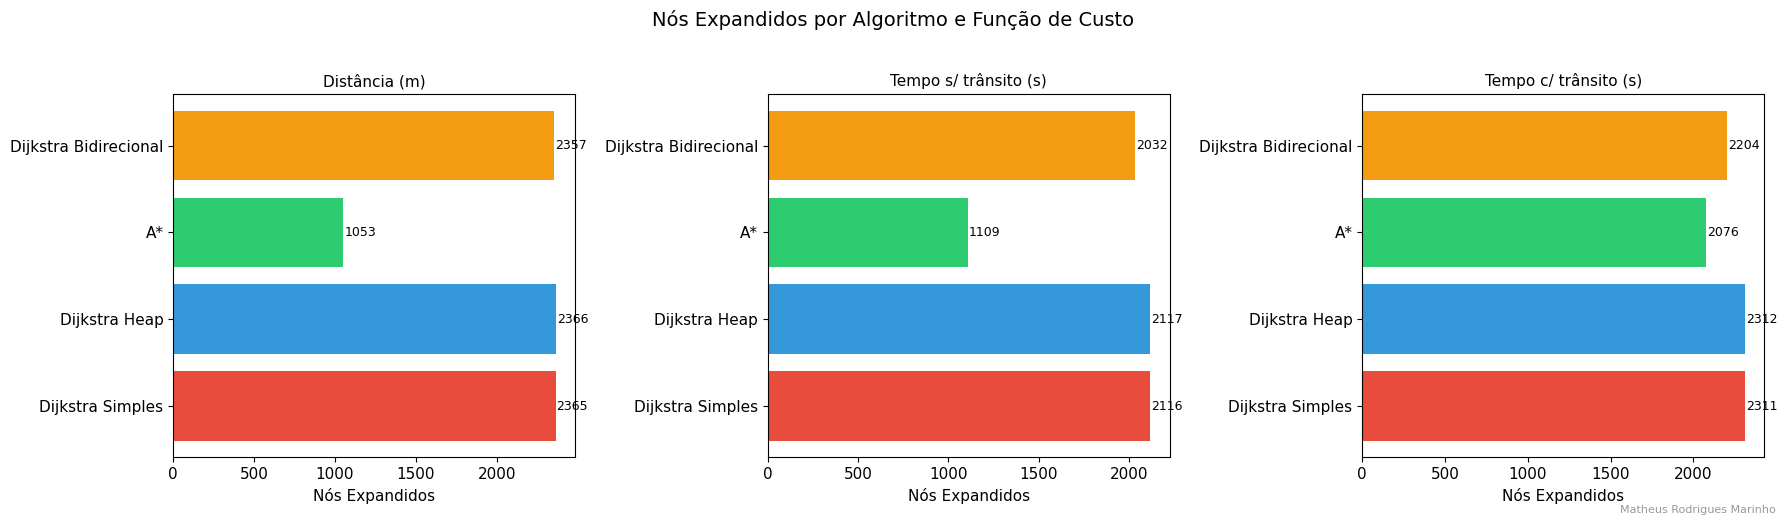

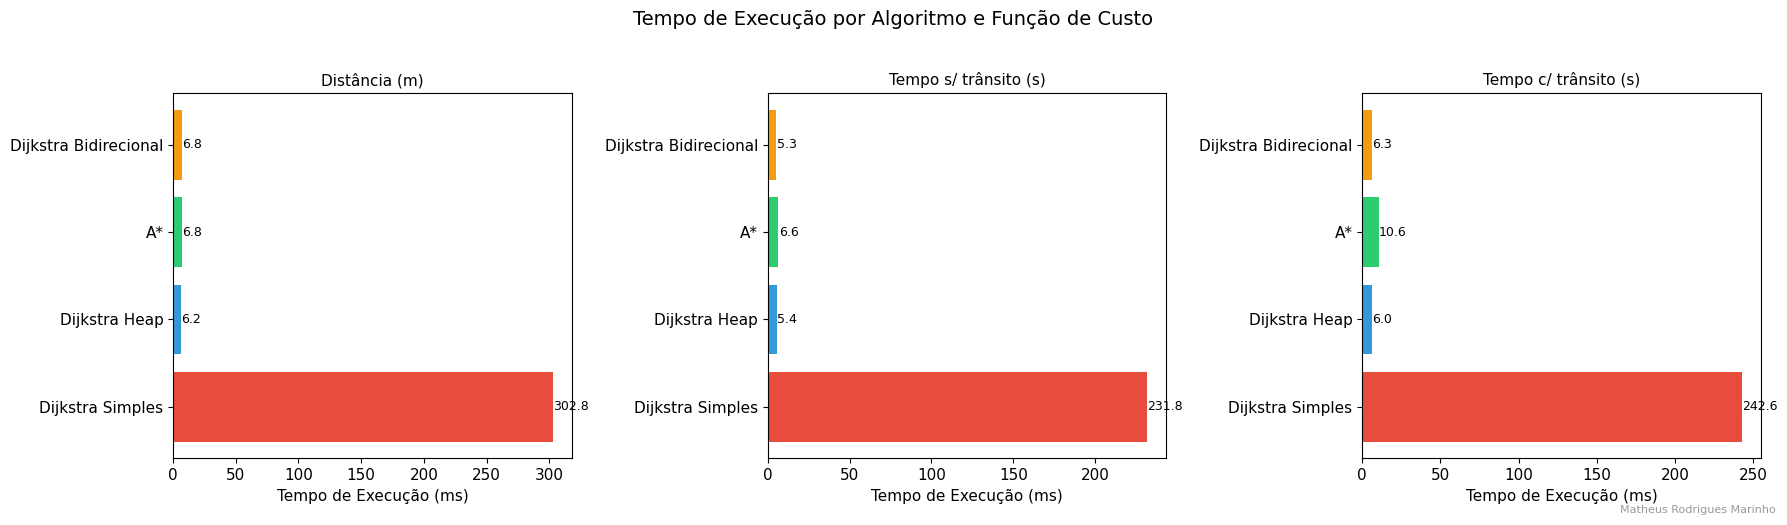

In [14]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
algo_names = list(algorithms.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (w_name, w_key) in enumerate(weights.items()):
    df_w = df_results[df_results['Peso'] == w_name]
    bars = axes[idx].barh(df_w['Algoritmo'], df_w['Nós Expandidos'], color=colors)
    axes[idx].set_title(w_name, fontsize=11)
    axes[idx].set_xlabel('Nós Expandidos')
    for bar, val in zip(bars, df_w['Nós Expandidos']):
        axes[idx].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                       str(val), va='center', fontsize=9)

plt.suptitle('Nós Expandidos por Algoritmo e Função de Custo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../imagens/02_nos_expandidos.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (w_name, w_key) in enumerate(weights.items()):
    df_w = df_results[df_results['Peso'] == w_name]
    bars = axes[idx].barh(df_w['Algoritmo'], df_w['Tempo Exec (ms)'], color=colors)
    axes[idx].set_title(w_name, fontsize=11)
    axes[idx].set_xlabel('Tempo de Execução (ms)')
    for bar, val in zip(bars, df_w['Tempo Exec (ms)']):
        axes[idx].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                       f'{val:.1f}', va='center', fontsize=9)

plt.suptitle('Tempo de Execução por Algoritmo e Função de Custo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../imagens/03_tempo_execucao.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análise de Caminhada

### 7.1 Busca de Pontos Candidatos P

Buscamos todos os nós a no máximo 500 metros de caminhada da origem A.
Para caminhada, convertemos o grafo para não-direcionado (pedestres ignoram mão única).
Usamos Dijkstra limitado por distância para encontrar os candidatos.

In [15]:
G_walk = G.to_undirected()

walk_dist = {A: 0}
walk_heap = [(0, A)]
walk_visited = set()

while walk_heap:
    d, u = heapq.heappop(walk_heap)
    if u in walk_visited:
        continue
    walk_visited.add(u)
    if d > MAX_WALK:
        break
    for v in G_walk.neighbors(u):
        if v not in walk_visited:
            edges = G_walk[u][v]
            w = min(edges[k].get('length', float('inf')) for k in edges)
            nd = d + w
            if nd <= MAX_WALK and nd < walk_dist.get(v, float('inf')):
                walk_dist[v] = nd
                heapq.heappush(walk_heap, (nd, v))

candidates = {n: d for n, d in walk_dist.items() if n != A and n in walk_visited}
print(f'Candidatos P encontrados (até {MAX_WALK}m de A): {len(candidates)}')
print(f'Distâncias de caminhada: mín={min(candidates.values()):.0f}m, '
      f'máx={max(candidates.values()):.0f}m, '
      f'média={np.mean(list(candidates.values())):.0f}m')

Candidatos P encontrados (até 500m de A): 29
Distâncias de caminhada: mín=45m, máx=475m, média=351m


### 7.2 Comparação: Direto (A→B) vs. Caminhada (A→P→B)

Para cada função de custo, encontramos o melhor ponto P que minimiza o custo total:

- Distância: dist_caminhada(A→P) + dist_carro(P→B)
- Tempo: tempo_caminhada(A→P) + tempo_carro(P→B), onde velocidade de caminhada = 5 km/h

In [16]:
best_P = {}

for w_name, w_key in weights.items():
    best_cost = float('inf')
    best_node = None
    best_path = None
    best_walk = 0

    for P, wd in candidates.items():
        path, drive_cost, _ = dijkstra_heap(G, P, B, weight=w_key)
        if not path:
            continue

        if w_key == 'length':
            total = wd + drive_cost
        else:
            walk_time = wd / WALK_SPEED
            total = walk_time + drive_cost

        if total < best_cost:
            best_cost = total
            best_node = P
            best_path = path
            best_walk = wd

    best_P[w_name] = {
        'node': best_node,
        'walk_dist': best_walk,
        'total_cost': best_cost,
        'path': best_path
    }

comparison = []
for w_name, w_key in weights.items():
    _, direct_cost, _ = dijkstra_heap(G, A, B, weight=w_key)
    p_info = best_P[w_name]
    gain = direct_cost - p_info['total_cost']
    gain_pct = (gain / direct_cost) * 100 if direct_cost > 0 else 0

    comparison.append({
        'Função de Custo': w_name,
        'Custo Direto (A→B)': round(direct_cost, 2),
        'Custo via P (A→P→B)': round(p_info['total_cost'], 2),
        'Caminhada (m)': round(p_info['walk_dist'], 1),
        'Ganho Absoluto': round(gain, 2),
        'Ganho (%)': round(gain_pct, 1)
    })

df_walk = pd.DataFrame(comparison)
print('\nComparação: Rota Direta vs. Rota com Caminhada')
print('=' * 80)
display(df_walk)


Comparação: Rota Direta vs. Rota com Caminhada


,Função de Custo,Custo Direto (A→B),Custo via P (A→P→B),Caminhada (m),Ganho Absoluto,Ganho (%)
0,Distância (m),5795.24,5463.16,328.9,332.08,5.7
1,Tempo s/ trânsito (s),380.76,387.72,44.6,-6.96,-1.8
2,Tempo c/ trânsito (s),730.61,768.29,44.6,-37.68,-5.2


## 8. Visualizações das Rotas

### 8.1 Rotas no Mapa (OSMnx)

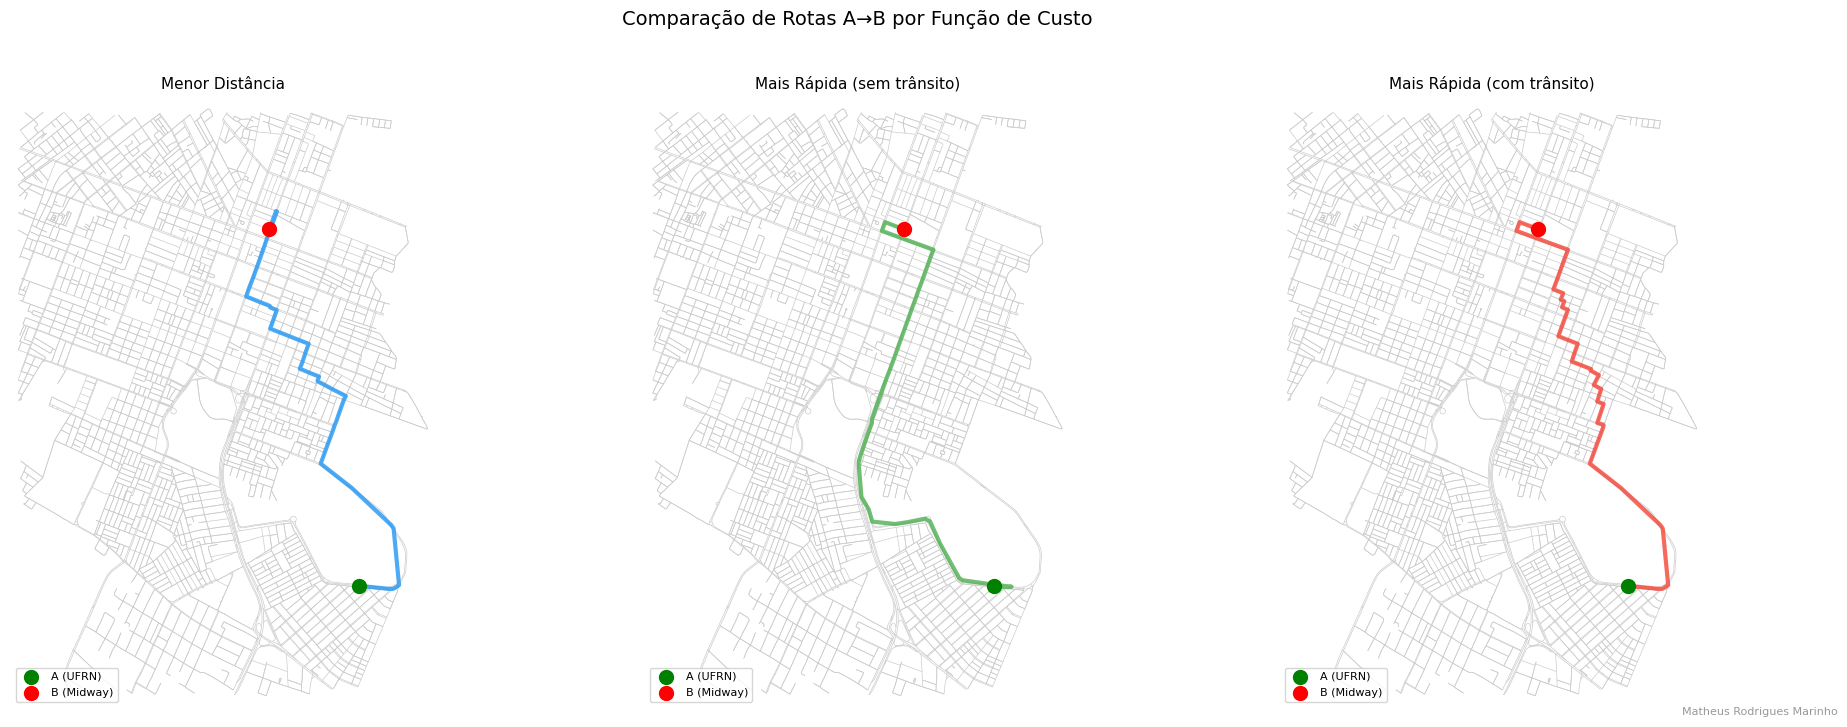

In [17]:
route_configs = [
    ('Distância (m)', 'Dijkstra Heap', '#2196F3', 'Menor Distância'),
    ('Tempo s/ trânsito (s)', 'Dijkstra Heap', '#4CAF50', 'Mais Rápida (sem trânsito)'),
    ('Tempo c/ trânsito (s)', 'Dijkstra Heap', '#F44336', 'Mais Rápida (com trânsito)'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (w_name, a_name, color, title) in enumerate(route_configs):
    route = routes[(w_name, a_name)]
    if route:
        ax = axes[idx]
        ox.plot_graph(G, ax=ax, node_size=0, edge_color='#cccccc',
                      edge_linewidth=0.5, bgcolor='white', show=False, close=False)
        path_coords = [(G.nodes[n]['x'], G.nodes[n]['y']) for n in route]
        xs, ys = zip(*path_coords)
        ax.plot(xs, ys, color=color, linewidth=3, alpha=0.8, zorder=5)
        ax.scatter([xs[0]], [ys[0]], c='green', s=100, zorder=6, label='A (UFRN)')
        ax.scatter([xs[-1]], [ys[-1]], c='red', s=100, zorder=6, label='B (Midway)')
        ax.set_title(title, fontsize=11)
        ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Comparação de Rotas A→B por Função de Custo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../imagens/04_rotas_comparadas.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Mapa Interativo com Rotas e Pontos P

In [18]:
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='CartoDB positron')

folium.Marker([G.nodes[A]['y'], G.nodes[A]['x']],
              popup='A: UFRN (Origem)', icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker([G.nodes[B]['y'], G.nodes[B]['x']],
              popup='B: Midway Mall (Destino)', icon=folium.Icon(color='red', icon='stop')).add_to(m)

folium.Circle([G.nodes[A]['y'], G.nodes[A]['x']],
              radius=MAX_WALK, color='green', fill=True, fill_opacity=0.08,
              popup=f'Raio de caminhada: {MAX_WALK}m').add_to(m)

route_colors = {
    'Distância (m)': ('#2196F3', 'Menor Distância'),
    'Tempo s/ trânsito (s)': ('#4CAF50', 'Mais Rápida (livre)'),
    'Tempo c/ trânsito (s)': ('#F44336', 'Mais Rápida (trânsito)')
}

for w_name, (color, label) in route_colors.items():
    route = routes[(w_name, 'Dijkstra Heap')]
    if route:
        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]
        folium.PolyLine(coords, color=color, weight=4, opacity=0.7,
                        tooltip=f'A→B: {label}').add_to(m)

p_colors = {
    'Distância (m)': 'purple',
    'Tempo s/ trânsito (s)': 'orange',
    'Tempo c/ trânsito (s)': 'darkred'
}

for w_name, color in p_colors.items():
    p_info = best_P[w_name]
    P = p_info['node']
    if P and P != A:
        folium.CircleMarker(
            [G.nodes[P]['y'], G.nodes[P]['x']],
            radius=8, color=color, fill=True, fill_opacity=0.8,
            popup=f'P ({w_name}): caminhada: {p_info["walk_dist"]:.0f}m'
        ).add_to(m)

        if p_info['path']:
            coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in p_info['path']]
            folium.PolyLine(coords, color=color, weight=3, opacity=0.5,
                            dash_array='10', tooltip=f'P→B ({w_name})').add_to(m)

m

### 8.3 Análise do Ganho por Distância de Caminhada

Para todos os candidatos P, plotamos o custo total (caminhada + carro) em função da distância de caminhada.

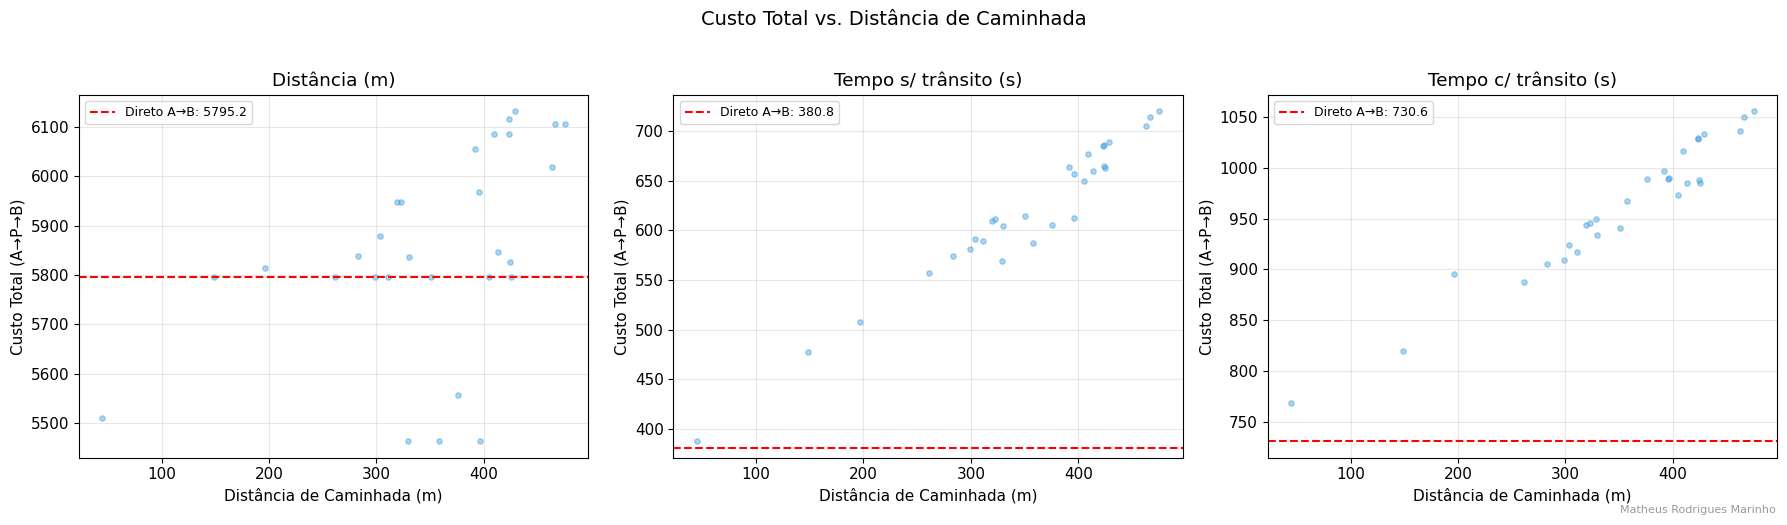

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (w_name, w_key) in enumerate(weights.items()):
    _, direct_cost, _ = dijkstra_heap(G, A, B, weight=w_key)
    walk_dists = []
    total_costs = []

    for P, wd in sorted(candidates.items(), key=lambda x: x[1]):
        path, drive_cost, _ = dijkstra_heap(G, P, B, weight=w_key)
        if not path:
            continue
        if w_key == 'length':
            total = wd + drive_cost
        else:
            total = (wd / WALK_SPEED) + drive_cost
        walk_dists.append(wd)
        total_costs.append(total)

    ax = axes[idx]
    ax.scatter(walk_dists, total_costs, alpha=0.4, s=15, color='#3498db')
    ax.axhline(y=direct_cost, color='red', linestyle='--', linewidth=1.5,
               label=f'Direto A→B: {direct_cost:.1f}')
    ax.set_xlabel('Distância de Caminhada (m)')
    ax.set_ylabel('Custo Total (A→P→B)')
    ax.set_title(w_name)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Custo Total vs. Distância de Caminhada', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../imagens/05_ganho_caminhada.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Resumo dos Resultados

In [20]:
print('=' * 80)
print('  RESUMO DOS RESULTADOS')
print('=' * 80)

print(f'\nGrafo: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas')
print(f'Origem: UFRN (nó {A})')
print(f'Destino: Midway Mall (nó {B})')
print(f'Raio de caminhada: {MAX_WALK}m')
print(f'Candidatos P: {len(candidates)}')

print('\n--- Algoritmos (rota direta A→B por distância) ---')
df_dist = df_results[df_results['Peso'] == 'Distância (m)']
for _, row in df_dist.iterrows():
    print(f"  {row['Algoritmo']:25s} | {row['Nós Expandidos']:5d} nós | {row['Tempo Exec (ms)']:8.2f} ms")

print('\n--- Ganho com caminhada ---')
for _, row in df_walk.iterrows():
    sinal = '+' if row['Ganho (%)'] > 0 else ''
    print(f"  {row['Função de Custo']:28s} | Ganho: {sinal}{row['Ganho (%)']:.1f}% "
          f"| Caminhada: {row['Caminhada (m)']:.0f}m")

  RESUMO DOS RESULTADOS

Grafo: 3374 nós, 8014 arestas
Origem: UFRN (nó 784697934)
Destino: Midway Mall (nó 501699027)
Raio de caminhada: 500m
Candidatos P: 29

--- Algoritmos (rota direta A→B por distância) ---
  Dijkstra Simples          |  2365 nós |   302.78 ms
  Dijkstra Heap             |  2366 nós |     6.25 ms
  A*                        |  1053 nós |     6.80 ms
  Dijkstra Bidirecional     |  2357 nós |     6.79 ms

--- Ganho com caminhada ---
  Distância (m)                | Ganho: +5.7% | Caminhada: 329m
  Tempo s/ trânsito (s)        | Ganho: -1.8% | Caminhada: 45m
  Tempo c/ trânsito (s)        | Ganho: -5.2% | Caminhada: 45m


## 10. Discussão

### 1. Como o problema foi modelado como grafo?

Pegamos a malha viária de Lagoa Nova e arredores (Natal/RN) do OpenStreetMap, via OSMnx. O resultado é um MultiDiGraph (direcionado e com arestas paralelas): os nós são interseções e pontas de rua; as arestas são os segmentos de via, com comprimento, velocidade e tipo de via.

### 2. O que representam os nós e as arestas?

- Nós: interseções e pontos onde uma rua muda de direção ou termina.
- Arestas: os trechos de rua entre duas interseções, com os atributos reais do OSM.

### 3. Quais pesos foram usados?

Três funções de custo:
1. Distância (`length`): comprimento em metros, para minimizar quilometragem.
2. Tempo sem trânsito (`travel_time`): usa a velocidade da via (OSM), o cenário livre.
3. Tempo com trânsito (`travel_time_traffic`): o tempo livre penalizado, simulando o pico.

### 4. Como o trânsito sintético alterou as rotas?

Ancoramos o congestionamento na geometria real das vias. Ele junta a hierarquia viária (avenidas saturam mais que ruas residenciais) com os corredores arteriais reais, identificados pelo nome no OSM, com destaque para a Av. Senador Salgado Filho (a via com mais arestas arteriais na área), além de Prudente de Morais, Nevaldo Rocha, Amintas Barros e outras. As arestas desses corredores ganham um reforço de congestionamento. No pico, o algoritmo passa a evitar essas avenidas e prefere caminhos alternativos, mesmo que mais longos em distância. Como o trânsito recai sobre as avenidas reais, o desvio fica fiel à cidade, em vez de parecer um sorteio aleatório por aresta.

### 5. Caminhar alguns metros melhorou a solução?

Depende da topologia local. Em alguns casos, sobretudo com trânsito, caminhar até um ponto P numa via mais livre chega a reduzir bastante o tempo total. O ganho costuma ser maior quando a origem fica numa região de acesso ruim.

### 6. Em quais casos caminhar atrapalhou?

Quando o ponto P fica fora da direção do destino: o desvio custa mais do que o alívio da via alternativa. Também quando a origem já está numa via principal com bom fluxo, aí andar até uma rua residencial pode até piorar o tempo.

### 7. A menor distância foi também a rota mais rápida?

Nem sempre. Ruas curtas podem ser lentas (residenciais, 30 km/h), enquanto avenidas mais longas chegam a 60 km/h. A rota mais curta e a mais rápida acabam divergindo, ainda mais numa rede com hierarquia viária clara como a de Lagoa Nova.

### 8. O A* expandiu menos nós que o Dijkstra?

Sim. A heurística haversine aponta a busca para o destino e evita gastar nós em direções opostas. A diferença cresce quando origem e destino estão distantes e a rede é densa.

### 9. O Dijkstra com Heap foi mais eficiente que o Dijkstra Simples?

Muito. O Dijkstra simples (O(V²)) é ordens de grandeza mais lento que a versão com heap (O((V+E) log V)). Num grafo com milhares de nós, essa diferença de tempo salta aos olhos.

### 10. O algoritmo da literatura trouxe algum ganho?

O Dijkstra bidirecional expandiu menos nós que o unidirecional com heap, porque busca dos dois lados ao mesmo tempo. O ganho aparece mais em grafos grandes; em redes pequenas, o custo de manter duas estruturas come parte do benefício.

### 11. Quais limitações existem na modelagem proposta?

1. Trânsito sintético: mesmo ancorado em vias reais (hierarquia + corredores pelo nome no OSM), os parâmetros (incremento por hierarquia, reforço dos corredores e severidade do pico) foram calibrados à mão e não substituem dados reais de fluxo.
2. Dados do OSM: as velocidades podem estar incompletas ou imprecisas em algumas vias.
3. Caminhada simplificada: usamos a rede de carros; pedestres podem cortar por praças e calçadas.
4. Grafo estático: não acompanha a variação contínua do trânsito ao longo do tempo.
5. Efeitos de borda: vias na beirada da área podem ter métricas distorcidas.

### 12. Como o modelo poderia ser aproximado de um aplicativo real de mobilidade?

1. Dados de trânsito reais: integrar APIs como Google Maps ou Waze para tempos atualizados.
2. Multimodalidade: incluir transporte público, bicicleta e patinete.
3. Tempo real: atualizar os pesos do grafo de forma contínua, com sensores.
4. Preferências do usuário: pesar segurança, conforto e custo de combustível.
5. Rede de pedestres: usar uma malha de calçadas separada da rede viária.
6. Predição de trânsito: estimar o congestionamento futuro com aprendizado de máquina.

## 11. Conclusão

Este projeto aplicou algoritmos de caminhos mínimos a um problema real de mobilidade em Lagoa Nova, Natal/RN. Os principais achados:

- O Dijkstra com Heap é ordens de grandeza mais rápido que o Dijkstra Simples, o que reforça o peso da estrutura de dados na eficiência.
- O A* corta bastante o número de nós expandidos ao usar a informação geográfica.
- O Dijkstra Bidirecional dá um ganho a mais por buscar dos dois lados ao mesmo tempo.
- A escolha dos pesos muda a rota: menor distância ≠ menor tempo.
- O trânsito altera bastante os caminhos, o que mostra a importância de considerá-lo na modelagem.
- Caminhar até outro ponto de embarque pode ajudar ou não: o trade-off depende da topologia e do congestionamento, e vale avaliar caso a caso.

---

Aluno: Matheus Rodrigues Marinho  
Disciplina: Estrutura de Dados II (DCA3702, Unidade 3)